## **SGD 기반 행렬 분해**

In [5]:
import numpy as np

R = np.array([[4, np.NaN, np.NaN, 2, np.NaN ],
              [np.NaN, 5, np.NaN, 3, 1 ],
              [np.NaN, np.NaN, 3, 4, 4 ],
              [5, 2, 1, 2, np.NaN ]])
num_users, num_items = R.shape
K=3

np.random.seed(1)
P = np.random.normal(scale=1./K, size=(num_users, K))
Q = np.random.normal(scale=1./K, size=(num_items, K))

In [7]:
from sklearn.metrics import mean_squared_error

def get_rmse(R, P, Q, non_zeros):
    error = 0
    full_pred_matrix = np.dot(P, Q.T)
    
    x_non_zero_ind = [non_zero[0] for non_zero in non_zeros]
    y_non_zero_ind = [non_zero[1] for non_zero in non_zeros]
    R_non_zeros = R[x_non_zero_ind, y_non_zero_ind]
    full_pred_matrix_non_zeros = full_pred_matrix[x_non_zero_ind, y_non_zero_ind]
      
    mse = mean_squared_error(R_non_zeros, full_pred_matrix_non_zeros)
    rmse = np.sqrt(mse)
    
    return rmse

In [9]:
non_zeros = [ (i, j, R[i,j]) for i in range(num_users) for j in range(num_items) if R[i,j] > 0 ]

steps=1000
learning_rate=0.01
r_lambda=0.01

for step in range(steps):
    for i, j, r in non_zeros:
        eij = r - np.dot(P[i, :], Q[j, :].T)
        P[i,:] = P[i,:] + learning_rate*(eij * Q[j, :] - r_lambda*P[i,:])
        Q[j,:] = Q[j,:] + learning_rate*(eij * P[i, :] - r_lambda*Q[j,:])

    rmse = get_rmse(R, P, Q, non_zeros)
    if (step % 50) == 0 :
        print("### iteration step : ", step," rmse : ", rmse)

### iteration step :  0  rmse :  3.2388050277987723
### iteration step :  50  rmse :  0.4876723101369647
### iteration step :  100  rmse :  0.15643403848192478
### iteration step :  150  rmse :  0.07455141311978043
### iteration step :  200  rmse :  0.043252267985793194
### iteration step :  250  rmse :  0.029248328780879015
### iteration step :  300  rmse :  0.02262111614382958
### iteration step :  350  rmse :  0.019493636196525124
### iteration step :  400  rmse :  0.01802271909213296
### iteration step :  450  rmse :  0.017319685953442937
### iteration step :  500  rmse :  0.016973657887570857
### iteration step :  550  rmse :  0.016796804595895498
### iteration step :  600  rmse :  0.016701322901884686
### iteration step :  650  rmse :  0.016644736912476636
### iteration step :  700  rmse :  0.016605910068210022
### iteration step :  750  rmse :  0.016574200475704817
### iteration step :  800  rmse :  0.016544315829216127
### iteration step :  850  rmse :  0.016513751774734887
###

In [11]:
pred_matrix = np.dot(P, Q.T)
print('예측 행렬:\n', np.round(pred_matrix, 3))

예측 행렬:
 [[3.991 0.897 1.306 2.002 1.663]
 [6.696 4.978 0.979 2.981 1.003]
 [6.677 0.391 2.987 3.977 3.986]
 [4.968 2.005 1.006 2.017 1.14 ]]


## **Surprise를 이용한 추천 시스템 구축**

In [14]:
from surprise import SVD
from surprise import Dataset 
from surprise import accuracy 
from surprise.model_selection import train_test_split

In [16]:
data = Dataset.load_builtin('ml-100k')
trainset, testset = train_test_split(data, test_size=.25, random_state=0) 

Dataset ml-100k could not be found. Do you want to download it? [Y/n] 

 ㅛ


Dataset ml-100k could not be found. Do you want to download it? [Y/n] 

 y


Trying to download dataset from https://files.grouplens.org/datasets/movielens/ml-100k.zip...
Done! Dataset ml-100k has been saved to C:\Users\SAMSUNG/.surprise_data/ml-100k


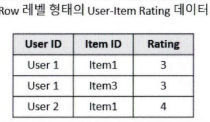

- 최신 무비렌즈 ratings.csv는 콤마(,)로 구분된 CSV 파일, 과거 버전은 탭(\t) 문자로 구분
- 무비렌즈 사이트에서 받은 데이터와 Surprise에서 제공하는 데이터는 분리 문자 등 포맷이 다를 수 있으므로, 동일하게 적용하면 오류가 발생할 수 있음
- Surprise에 사용자-아이템 평점 데이터를 적용할 때는 데이터 포맷(분리 문자 등)을 확인하고 맞춰야 함
- Surprise는 자체적으로 데이터 포맷을 변환해 사용하므로, 외부 데이터셋을 사용할 경우 반드시 포맷을 확인하기


In [20]:
algo = SVD(random_state=0)
algo.fit(trainset) 

In [22]:
predictions = algo.test( testset )
print('prediction type :',type(predictions), ' size:',len(predictions))
print('prediction 결과의 최초 5개 추출')
predictions[:5]

prediction type : <class 'list'>  size: 25000
prediction 결과의 최초 5개 추출


[Prediction(uid='120', iid='282', r_ui=4.0, est=3.5114147666251547, details={'was_impossible': False}),
 Prediction(uid='882', iid='291', r_ui=4.0, est=3.573872419581491, details={'was_impossible': False}),
 Prediction(uid='535', iid='507', r_ui=5.0, est=4.033583485472447, details={'was_impossible': False}),
 Prediction(uid='697', iid='244', r_ui=5.0, est=3.8463639495936905, details={'was_impossible': False}),
 Prediction(uid='751', iid='385', r_ui=4.0, est=3.1807542478219157, details={'was_impossible': False})]

- 입력 인자 데이터 세트 크기(예: 25,000개)만큼의 리스트 형태 결과가 반환
- 각 Prediction 객체에는 Surprise 패키지에서 제공하는 데이터 타입 포함
  - 개별 사용자 아이디(uid)
  - 영화(또는 아이템) 아이디(iid)
  - 실제 평점(r_ui)
  - Surprise가 예측한 평점(est)
- was_impossible이 True이면 예측값을 생성할 수 없는 데이터임을 의미하며, 여기서는 모두 False

In [25]:
[ (pred.uid, pred.iid, pred.est) for pred in predictions[:3] ]

[('120', '282', 3.5114147666251547),
 ('882', '291', 3.573872419581491),
 ('535', '507', 4.033583485472447)]

In [27]:
uid = str(196)
iid = str(302)
pred = algo.predict(uid, iid)
print(pred)

user: 196        item: 302        r_ui = None   est = 4.49   {'was_impossible': False}


- 개별 사용자의 아이템에 대한 추천 평점을 예측함

In [30]:
accuracy.rmse(predictions)

RMSE: 0.9467


0.9466860806937948

## **Surprise 주요 모듈 소개**

In [35]:
import pandas as pd

ratings = pd.read_csv('./ml-latest-small/ratings.csv')
ratings.to_csv('./ml-latest-small/ratings_noh.csv', index=False, header=False)

In [37]:
from surprise import Reader

reader = Reader(line_format='user item rating timestamp', sep=',', rating_scale=(0.5, 5))
data=Dataset.load_from_file('./ml-latest-small/ratings_noh.csv',reader=reader)

-> ratings_noh.csv 파일에 timestamp 컬럼이 포함되어 있어도, Surprise는 앞 3개 컬럼(user, item, rating)만 로딩


- Surprise 데이터 파일 형식 및 Reader 주요 파라미터
</br>Surprise 데이터 파일은 기본적으로 무비렌즈 등과 같은 무피헤더(헤더 없는) 데이터 형식을 요구함. 파일의 컬럼 순서와 구분자, 평점 범위 등은 Reader 클래스를 통해 반드시 명확히 지정해야 함.
- 주요 파라미터
  - line_format (string):
데이터 각 컬럼의 순서를 공백으로 구분해 지정.
입력된 순서대로 데이터 파일의 컬럼을 인식함.
  - sep (char) : 
컬럼을 구분하는 문자
  - rating_scale (tuple, optional):
평점의 최소, 최대값을 지정. 
ratings.csv 파일의 평점 범위에 맞춰 설정해야 함.

In [40]:
trainset, testset = train_test_split(data, test_size=.25, random_state=0)

algo = SVD(n_factors=50, random_state=0)

algo.fit(trainset) 
predictions = algo.test( testset )
accuracy.rmse(predictions)

RMSE: 0.8682


0.8681952927143516

- 판다스 DataFrame에서 Suprise 데이터 세트로 로딩 

In [43]:
import pandas as pd
from surprise import Reader, Dataset

ratings = pd.read_csv('./ml-latest-small/ratings.csv') 
reader = Reader(rating_scale=(0.5, 5.0))

data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)
trainset, testset = train_test_split(data, test_size=.25, random_state=0)

algo = SVD(n_factors=50, random_state=0)
algo.fit(trainset) 
predictions = algo.test( testset )
accuracy.rmse(predictions)

RMSE: 0.8682


0.8681952927143516

## **교차 검증과 하이퍼 파라미터 튜닝**

Surprise는 교차 검증과 하이퍼 파라미터 튜님을 위해 사이킷런과 유사한 cross_validate()와 CridSearchCV 클래스를 제공

In [49]:
from surprise.model_selection import cross_validate

ratings = pd.read_csv('./ml-latest-small/ratings.csv') # reading data in pandas df
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

algo = SVD(random_state=0)
cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8739  0.8639  0.8700  0.8787  0.8775  0.8728  0.0054  
MAE (testset)     0.6704  0.6644  0.6710  0.6747  0.6739  0.6709  0.0036  
Fit time          1.00    1.00    1.11    1.08    1.02    1.04    0.04    
Test time         0.08    0.10    0.19    0.09    0.10    0.11    0.04    


{'test_rmse': array([0.87386097, 0.86385394, 0.87001019, 0.87869206, 0.87754842]),
 'test_mae': array([0.67040961, 0.66442237, 0.67098542, 0.67468529, 0.67385167]),
 'fit_time': (1.0017001628875732,
  1.0029034614562988,
  1.1057696342468262,
  1.0764319896697998,
  1.0185282230377197),
 'test_time': (0.08444833755493164,
  0.10113239288330078,
  0.18674874305725098,
  0.09435153007507324,
  0.09557366371154785)}

-> 폴드별 성능 평가 수치와 전체 폴드의 평균 성능 평가 수치를 함께 보여줌 

In [52]:
from surprise.model_selection import GridSearchCV

# 최적화할 파라미터를 딕셔너리 형태로 지정.
param_grid = {'n_epochs': [20, 40, 60], 'n_factors': [50, 100, 200] }

gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3)
gs.fit(data)

print(gs.best_score['rmse'])
print(gs.best_params['rmse'])

0.8779338881055662
{'n_epochs': 20, 'n_factors': 50}


-> 20에폭, factor 50개일 때 3개의 폴드 검증 데이터 세트에서 최적 RMSE가 약 0.8779로 도출

## **Surprise를 이용한 개인화 영화 추천 시스템 구축**

Surprise 패키리를 이용해 학습된 추천 알고리즘을 기반으로 특정 사용자가 아직 평점을 매기지 않은 영화 중에서 개인 취향에 가장 적절한 영화를 추천해보자. 

In [60]:
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)
algo = SVD(n_factors=50, random_state=0)
algo.fit(data)

AttributeError: 'DatasetAutoFolds' object has no attribute 'n_users'

-> Surprise는 데이터 세트를 내부에서 사용하는 TrainSet 클래스 객체로 변환하지 않으면 fit을 통해 학습 불가

In [63]:
from surprise.dataset import DatasetAutoFolds

reader = Reader(line_format='user item rating timestamp', sep=',', rating_scale=(0.5, 5))
data_folds = DatasetAutoFolds(ratings_file='./ml-latest-small/ratings_noh.csv', reader=reader)

trainset = data_folds.build_full_trainset()

In [65]:
algo = SVD(n_epochs=20, n_factors=50, random_state=0)
algo.fit(trainset)

In [67]:
movies = pd.read_csv('./ml-latest-small/movies.csv')

# movieId=42 데이터가 있는지 확인. 
movieIds = ratings[ratings['userId']==9]['movieId']
if movieIds[movieIds==42].count() == 0:
    print('사용자 아이디 9는 영화 아이디 42의 평점 없음')

print(movies[movies['movieId']==42])

사용자 아이디 9는 영화 아이디 42의 평점 없음
    movieId                   title              genres
38       42  Dead Presidents (1995)  Action|Crime|Drama


In [69]:
uid = str(9)
iid = str(42)

pred = algo.predict(uid, iid, verbose=True)

user: 9          item: 42         r_ui = None   est = 3.13   {'was_impossible': False}


-> 추천 예측 평점 est는 3.13

In [72]:
def get_unseen_surprise(ratings, movies, userId):
    seen_movies = ratings[ratings['userId']== userId]['movieId'].tolist()
    
    total_movies = movies['movieId'].tolist()
    
    unseen_movies= [movie for movie in total_movies if movie not in seen_movies]
    print('평점 매긴 영화수:',len(seen_movies), '추천대상 영화수:',len(unseen_movies), \
          '전체 영화수:',len(total_movies))
    
    return unseen_movies

unseen_movies = get_unseen_surprise(ratings, movies, 9)

평점 매긴 영화수: 46 추천대상 영화수: 9696 전체 영화수: 9742


In [74]:
def recomm_movie_by_surprise(algo, userId, unseen_movies, top_n=10):
    predictions = [algo.predict(str(userId), str(movieId)) for movieId in unseen_movies]
    
    def sortkey_est(pred):
        return pred.est
    
    predictions.sort(key=sortkey_est, reverse=True)
    top_predictions= predictions[:top_n]
    
    top_movie_ids = [ int(pred.iid) for pred in top_predictions]
    top_movie_rating = [ pred.est for pred in top_predictions]
    top_movie_titles = movies[movies.movieId.isin(top_movie_ids)]['title']
    top_movie_preds = [ (id, title, rating) for id, title, rating in zip(top_movie_ids, top_movie_titles, top_movie_rating)]
    
    return top_movie_preds

In [76]:
unseen_movies = get_unseen_surprise(ratings, movies, 9)
top_movie_preds = recomm_movie_by_surprise(algo, 9, unseen_movies, top_n=10)
print('##### Top-10 추천 영화 리스트 #####')

for top_movie in top_movie_preds:
    print(top_movie[1], ":", top_movie[2])

평점 매긴 영화수: 46 추천대상 영화수: 9696 전체 영화수: 9742
##### Top-10 추천 영화 리스트 #####
Usual Suspects, The (1995) : 4.306302135700814
Star Wars: Episode IV - A New Hope (1977) : 4.281663842987387
Pulp Fiction (1994) : 4.278152632122759
Silence of the Lambs, The (1991) : 4.226073566460876
Godfather, The (1972) : 4.1918097904381995
Streetcar Named Desire, A (1951) : 4.154746591122658
Star Wars: Episode V - The Empire Strikes Back (1980) : 4.122016128534504
Star Wars: Episode VI - Return of the Jedi (1983) : 4.108009609093436
Goodfellas (1990) : 4.083464936588478
Glory (1989) : 4.07887165526957
